<a href="https://colab.research.google.com/github/dominicwooldridge/GSB-S544/blob/Practice-Activities/Copy_of_Practice_Activity_9_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

## The Data

At this link, you will find a dataset containing information about heart disease patients: https://www.dropbox.com/scl/fi/0vrpdnq5asmeulc4gd50y/ha_1.csv?rlkey=ciisalceotl77ffqhqe3kujzv&dl=1

A description of the original dataset can be found here: https://archive.ics.uci.edu/dataset/45/heart+disease (However, this dataset has been cleaned and reduced, and the people have been given fictious names.)

In [3]:
import pandas as pd

url = "https://www.dropbox.com/scl/fi/0vrpdnq5asmeulc4gd50y/ha_1.csv?rlkey=ciisalceotl77ffqhqe3kujzv&dl=1"

heart = pd.read_csv(url)

heart.head()


,Name,age,sex,cp,trtbps,chol,restecg,thalach,diagnosis
0,Magnolia Cassin,60,1,1,117,230,1,160,No Disease
1,Dr. Cathern Heathcote,60,0,3,102,318,1,160,Disease
2,Miles Wolf,62,0,3,130,263,1,97,No Disease
3,Mikaila Block,43,1,1,115,303,1,181,Disease
4,Mrs. Jacquline Marquardt,66,1,1,120,302,0,151,Disease


In [4]:
heart = pd.get_dummies(heart, columns=['diagnosis'])
heart.head()


,Name,age,sex,cp,trtbps,chol,restecg,thalach,diagnosis_Disease,diagnosis_No Disease
0,Magnolia Cassin,60,1,1,117,230,1,160,False,True
1,Dr. Cathern Heathcote,60,0,3,102,318,1,160,True,False
2,Miles Wolf,62,0,3,130,263,1,97,False,True
3,Mikaila Block,43,1,1,115,303,1,181,True,False
4,Mrs. Jacquline Marquardt,66,1,1,120,302,0,151,True,False


## 1. Logistic Regression

Fit a Logistic Regression using only `age` and `chol` (cholesterol) as predictors.

For a 55 year old, how high would their cholesterol need to be for the doctors to predict heart disease is present?

How high for the doctors to estimate a 90% chance that heart disease is present?

In [5]:
from sklearn.linear_model import LogisticRegression

X = heart[['age', 'chol']]
y = heart['diagnosis_Disease']

log_reg = LogisticRegression()
log_reg.fit(X, y)

print("Intercept:", log_reg.intercept_)
print("Coefficients:", log_reg.coef_)

Intercept: [3.24011226]
Coefficients: [[-0.04686331 -0.00180124]]


In [6]:

intercept = log_reg.intercept_[0]
b_age, b_chol = log_reg.coef_[0]

age = 55

chol_threshold = (-intercept - b_age * age) / b_chol
chol_threshold


np.float64(367.8748897985851)

In [8]:
import numpy as np
intercept = log_reg.intercept_[0]
b_age, b_chol = log_reg.coef_[0]



## 2. Linear Discriminant Analysis

Fit an LDA model using only `age` and `chol` (cholesterol)  as predictors.

For a 55 year old, how high would their cholesterol need to be for the doctors to predict heart disease is present?

In [10]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split

X = heart[["age", "chol"]]
y = heart["diagnosis_Disease"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


lda = LinearDiscriminantAnalysis()


lda.fit(X_train, y_train)


accuracy = lda.score(X_test, y_test)
print("LDA accuracy:", accuracy)


LDA accuracy: 0.5609756097560976


In [11]:
import numpy as np


w = lda.coef_[0]
b = lda.intercept_[0]

age = 55

chol_threshold = -(b + w[0] * age) / w[1]

print("Cholesterol threshold for age 55:", chol_threshold)


Cholesterol threshold for age 55: 383.5489269044824


## 3. Support Vector Classifier

Fit an SVC model using only `age` and `chol` as predictors.  Don't forget to tune the regularization parameter.

For a 55 year old, how high would their cholesterol need to be for the doctors to predict heart disease is present?

In [20]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


X = heart[["age", "chol"]]
y = heart["diagnosis_Disease"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

svc_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", probability=True, random_state=42))
])

svc_clf.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('svc', SVC(probability=True, random_state=42))])

In [21]:
import numpy as np
import pandas as pd

svc = svc_clf.named_steps["svc"]
print("Classes:", svc.classes_)   # should print: [0 1]

# index of the "disease" class (1)
disease_idx = np.where(svc.classes_ == 1)[0][0]

def prob_disease_svc(chol, age=55):
    X_new = pd.DataFrame({"age": [age], "chol": [chol]})
    proba = svc_clf.predict_proba(X_new)[0, disease_idx]
    return proba


Classes: [False  True]


In [22]:
for c in [150, 180, 210, 240, 270, 300]:
    print(c, prob_disease_svc(c))


150 0.7036909227481666
180 0.7146794966514385
210 0.6419252614240366
240 0.47715574122714455
270 0.3919409054370924
300 0.44593013525422137


In [23]:
chol_min = heart["chol"].min()
chol_max = heart["chol"].max()

chol_values = np.linspace(chol_min, chol_max, 1000)
probs = np.array([prob_disease_svc(c, age=55) for c in chol_values])

idxs_50 = np.where(probs >= 0.50)[0]

if len(idxs_50) == 0:
    print("For a 55-year-old, the SVC model never reaches 50% risk over this cholesterol range.")
else:
    chol_50 = chol_values[idxs_50[0]]
    print("Chol threshold for 50% risk at age 55:", chol_50)


Chol threshold for 50% risk at age 55: 126.0


## 4. Comparing Decision Boundaries

Make a scatterplot of `age` and `chol`, coloring the points by their true disease outcome.  Add a line to the plot representing the **linear separator** (aka **decision boundary**) for each of the three models above.

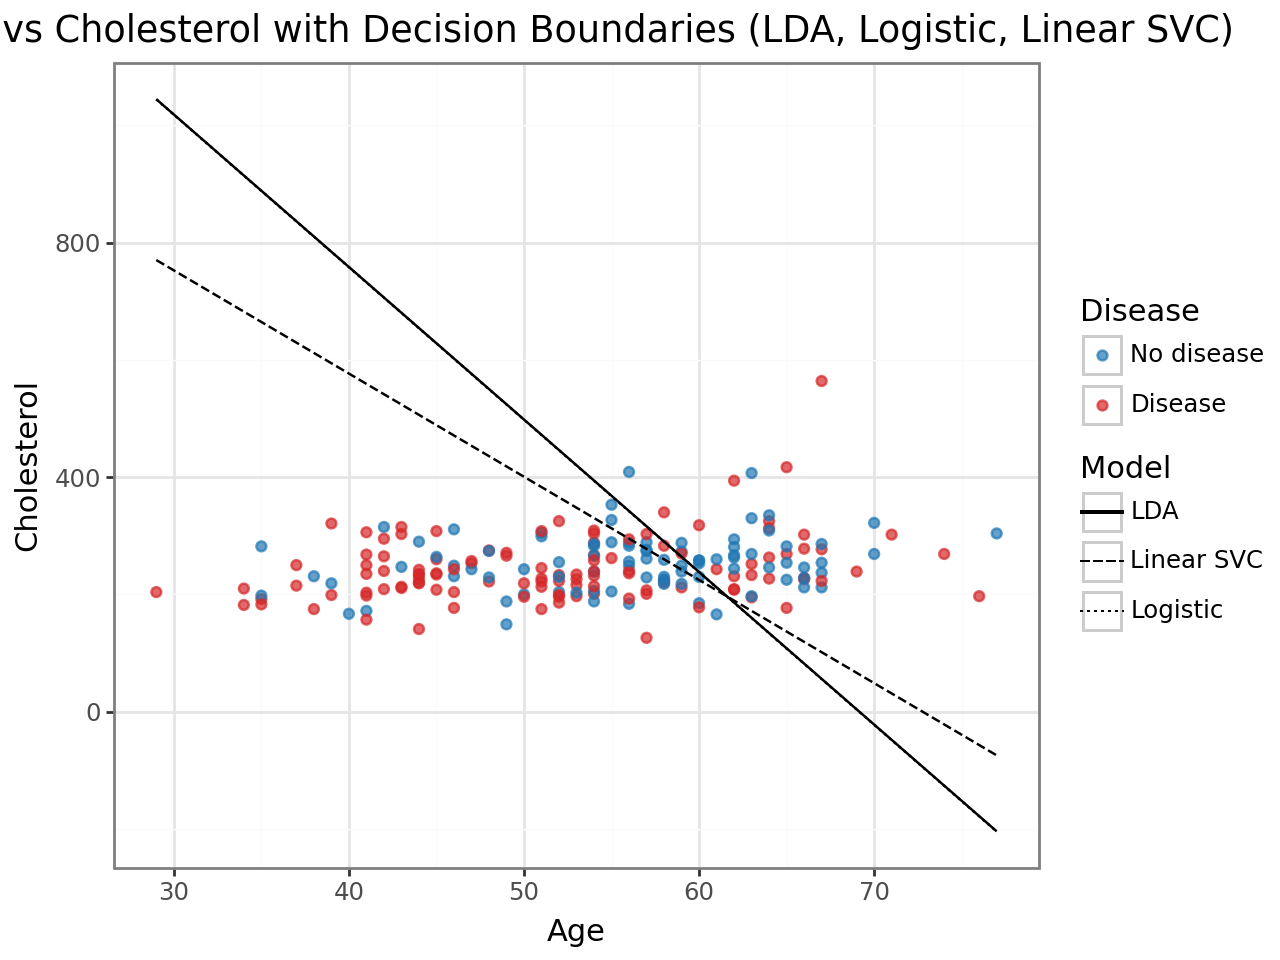

In [25]:
import numpy as np
import pandas as pd

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from plotnine import (
    ggplot, aes, geom_point, geom_line,
    labs, scale_color_manual, scale_linetype_manual,
    theme_bw
)


X = heart[["age", "chol"]]
y = heart["diagnosis_Disease"]


lda = LinearDiscriminantAnalysis()
lda.fit(X, y)

log_reg = LogisticRegression()
log_reg.fit(X, y)

svc_linear = SVC(kernel="linear")
svc_linear.fit(X, y)


age_grid = np.linspace(X["age"].min(), X["age"].max(), 200)


w_lda = lda.coef_[0]
b_lda = lda.intercept_[0]
chol_lda = -(w_lda[0] * age_grid + b_lda) / w_lda[1]


w_log = log_reg.coef_[0]
b_log = log_reg.intercept_[0]
chol_log = -(w_log[0] * age_grid + b_log) / w_log[1]


w_svc = svc_linear.coef_[0]
b_svc = svc_linear.intercept_[0]
chol_svc = -(w_svc[0] * age_grid + b_svc) / w_svc[1]


df_lda = pd.DataFrame({"age": age_grid, "chol": chol_lda, "model": "LDA"})
df_log = pd.DataFrame({"age": age_grid, "chol": chol_log, "model": "Logistic"})
df_svc = pd.DataFrame({"age": age_grid, "chol": chol_svc, "model": "Linear SVC"})

df_lines = pd.concat([df_lda, df_log, df_svc], ignore_index=True)


df_points = heart[["age", "chol", "diagnosis_Disease"]].copy()
df_points["diagnosis_Disease"] = df_points["diagnosis_Disease"].astype("category")

p = (
    ggplot(df_points, aes("age", "chol", color="factor(diagnosis_Disease)"))
    + geom_point(alpha=0.7)
    + geom_line(
        df_lines,
        aes("age", "chol", linetype="model"),
        inherit_aes=False
    )
    + scale_color_manual(
        values=["#1f77b4", "#d62728"],
        name="Disease",
        labels=["No disease", "Disease"]
    )
   + scale_linetype_manual(
    values=["solid", "dashed", "dotted"],
    name="Model"


    )
    + labs(
        x="Age",
        y="Cholesterol",
        title="Age vs Cholesterol with Decision Boundaries (LDA, Logistic, Linear SVC)"
    )
    + theme_bw()
)

p
